In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('/content/drive/MyDrive/insurance.csv')

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape

(1338, 7)

In [8]:
df.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
print(df.isnull().sum())
print("Total missing values in dataset: ",df.isnull().sum().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Total missing values in dataset:  0


In [12]:
print("Duplicates values: ",df.duplicated().sum())

Duplicates values:  1


In [13]:
df = df.drop_duplicates()
print("Duplicates value after removal: ",df.duplicated().sum())

Duplicates value after removal:  0


In [14]:
print("Categorical columns in dataset: ",df.select_dtypes(include="object").columns.tolist())


Categorical columns in dataset:  ['sex', 'smoker', 'region']


In [15]:
print("Dataset before preprocessing\n",df.head())

Dataset before preprocessing
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [16]:
df_ml = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)
print(df.head())
print("\nNew column names:")
print(df.columns.tolist())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

New column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [17]:
print("FINAL DATASET PREPARED FOR ML, After Preprocessing\n")

print(df.head())

print("\nFinal Shape:", df.shape)

print("\nFinal Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

FINAL DATASET PREPARED FOR ML, After Preprocessing

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Final Shape: (1337, 7)

Final Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
print("Shape:", df.shape)
display(df.head())
print(df.info())

Shape: (1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
None


Correlation Analysis

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


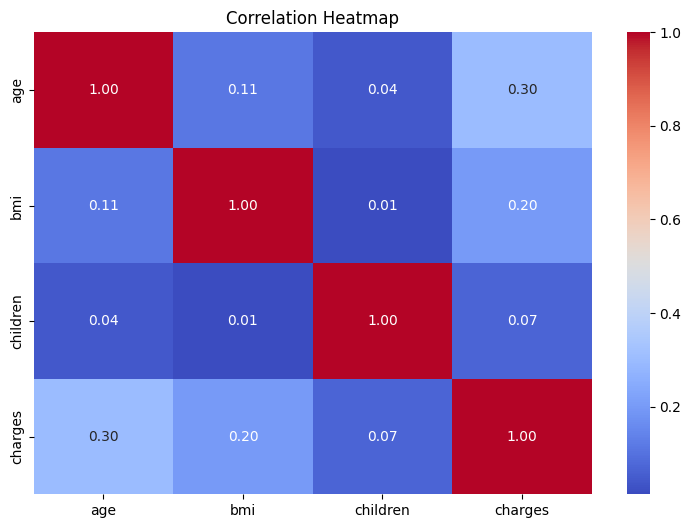

In [20]:
print("Correlation Analysis\n")

numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

print(correlation)

plt.figure(figsize=(9, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


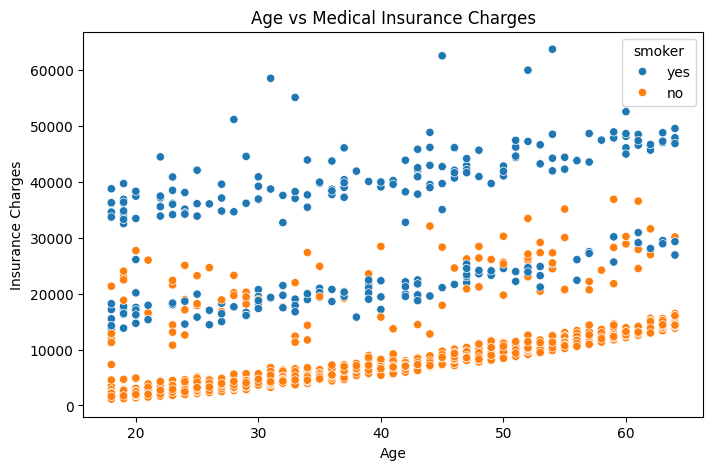

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

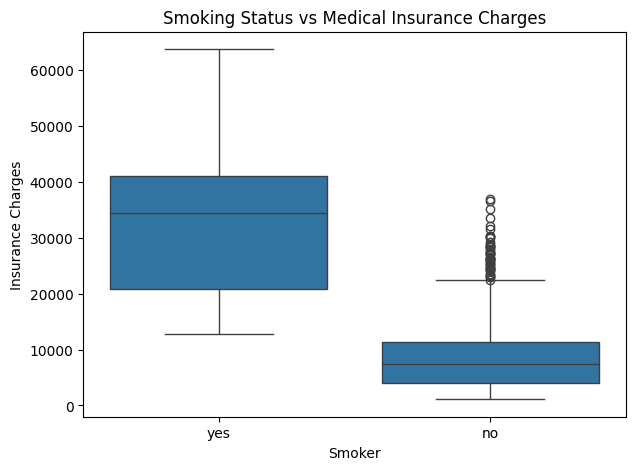

In [22]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Smoking Status vs Medical Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")
plt.show()


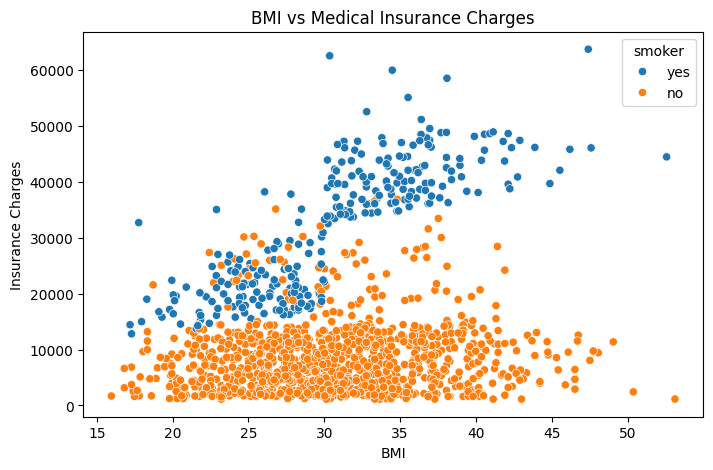

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()


In [24]:
print("Important Observations")

# Correlation with charges
print("\nCorrelation with charges:")
print(correlation["charges"].sort_values(ascending=False))

# Average charges by smoking status
print("\nAverage charges by smoking status:")
print(df.groupby("smoker")["charges"].mean())

# Average charges by sex
print("\nAverage charges by sex:")
print(df.groupby("sex")["charges"].mean())

# Average charges by region
print("\nAverage charges by region:")
print(df.groupby("region")["charges"].mean())

Important Observations

Correlation with charges:
charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64

Average charges by smoking status:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

Average charges by sex:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

Average charges by region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [31]:
X = df_ml.drop("charges", axis=1)
y = df_ml["charges"]


print(" X AND y PREPARATION ")
print("\n")

print("X (Features):")
display(X.head())

print("X shape:", X.shape)

print("\ny (Target):")
display(y.head())

print("y shape:", y.shape)

 X AND y PREPARATION 


X (Features):


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


X shape: (1337, 8)

y (Target):


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


y shape: (1337,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

print(" Train Test & Split \n")


print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


 Train Test & Split 

Training features: (1069, 8)
Testing features: (268, 8)
Training target: (1069,)
Testing target: (268,)


In [35]:
model = LinearRegression()

print(" Linear Regression Model\n")

print("Model created successfully:")
print(model)


 Linear Regression Model

Model created successfully:
LinearRegression()


In [36]:
model.fit(X_train, y_train)

print("Model Training\n")

print(" model trained successfully!")

Model Training

 model trained successfully!


In [37]:
y_pred = model.predict(X_test)

print("Sample Predictions \n")

prediction_df = pd.DataFrame({
    "Actual Charges": y_test.values[:10],
    "Predicted Charges": y_pred[:10]
})

display(prediction_df)

Sample Predictions 



,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [42]:
#  MODEL EVALUATION
import numpy as np
import pandas as pd

In [43]:
# Calculate errors
errors = y_test - y_pred

In [44]:
# Mean Absolute Error (MAE)
mae = np.mean(np.abs(errors))
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 4177.05


In [45]:
# Mean Squared Error (MSE)
mse = np.mean(errors ** 2)
print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 35478020.68


In [46]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 5956.34


In [47]:
# 5. R² Score
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Root Mean Squared Error (RMSE): 5956.34


In [48]:
# Create Actual vs Predicted DataFrame

comparison = pd.DataFrame({
    "Actual Charges": y_test,
    "Predicted Charges": y_pred
})

# Calculate difference
comparison["Absolute Error"] = np.abs(
    comparison["Actual Charges"] - comparison["Predicted Charges"]
)

display(comparison.head(10))

,Actual Charges,Predicted Charges,Absolute Error
900,8688.85885,8143.693884,545.164966
1064,5708.86700,5737.115683,28.248683
1256,11436.73815,14369.314876,2932.576726
298,38746.35510,31745.513636,7000.841464
237,4463.20510,8962.386657,4499.181557
481,9304.70190,13149.722353,3845.020453
240,38511.62830,30446.760679,8064.867621
277,2150.46900,1453.288813,697.180187
415,7345.72660,10633.018402,3287.291802
707,10264.44210,11318.943794,1054.501694
